# CellPin Tutorial

CellPin imputes the missing genes of spatially-resolved cells by leveraging a single-cell RNA reference data.  
This notebook walks through three complete workflows:

| Section | Description |
|---------|-------------|
| **A — Standard** | Train on all overlapping genes and impute the full reference gene space |
| **B — Held-out evaluation** | Hold out panel genes before training to benchmark imputation accuracy |

**Before running:** update the file paths in *Load data* cell to point to your own `.h5ad` files.

## Setup

In [1]:
import cellpin
import torch
import scanpy as sc
import numpy as np
import yaml
from pathlib import Path
from time import time


## Helper functions

Two evaluation helpers used throughout the notebook:

- `correlation_panel` — mean Pearson correlation between observed and imputed counts for the training panel genes  
- `correlation_heldout` — same metric, but restricted to genes that were **held out** during training (Option B only)

In [2]:
def correlation_panel(adata_imputed, layer_real, layer_imputed):
    """Mean per-gene Pearson r between two layers. Genes with -2 sentinel are excluded."""
    counts_mat = adata_imputed.layers[layer_real]
    imputed_mat = adata_imputed.layers[layer_imputed]
    if hasattr(counts_mat, "toarray"):
        counts_mat = counts_mat.toarray()
    if hasattr(imputed_mat, "toarray"):
        imputed_mat = imputed_mat.toarray()

    valid_idx = np.where(~(counts_mat == -2).any(axis=0))[0]
    pearsons = []
    for j in valid_idx:
        x, y = counts_mat[:, j], imputed_mat[:, j]
        if np.std(x) > 0 and np.std(y) > 0:
            pearsons.append(np.corrcoef(x, y)[0, 1])
        else:
            pearsons.append(np.nan)

    mean_r = np.nanmean(pearsons)
    print(f"Valid genes (no sentinel): {len(valid_idx)}")
    print(f"Mean Pearson r           : {mean_r:.4f}")


def correlation_heldout(adata_imputed, sp_adata_full, heldout_genes, layer_real="counts", layer_imputed="imputed"):
    """Evaluate imputation accuracy on genes held out during training."""
    assert sp_adata_full.n_obs == adata_imputed.n_obs, "Cell count mismatch between sp_adata_full and adata_imputed."

    pearsons = []
    for gene in heldout_genes:
        if gene not in sp_adata_full.var_names or gene not in adata_imputed.var_names:
            print(f"  [{gene}] not found — skipping")
            continue
        real = sp_adata_full[:, gene].layers[layer_real].toarray().flatten().astype(float)
        imputed = adata_imputed[:, gene].layers[layer_imputed].toarray().flatten().astype(float)
        if np.std(real) == 0 or np.std(imputed) == 0:
            print(f"  [{gene}] zero variance — skipping")
            continue
        r = np.corrcoef(real, imputed)[0, 1]
        pearsons.append(r)
        print(f"  {gene:20s}  Pearson = {r:.4f}")

    mean_r = np.nanmean(pearsons)
    print(f"\nMean Pearson over {len(pearsons)} held-out genes: {mean_r:.4f}")

---
# A) Standard Workflow — Full Panel

The standard CellPin workflow in four steps:

1. Load a single-cell reference (`sc_adata`) and a spatial dataset (`sp_adata`)  
2. Run `cellpin.pp.setup_data()` to align gene spaces  
3. Train a `CellPin` model on the scRNA reference  
4. Impute the full gene space for every spatial cell  

All overlapping genes between the two datasets are used as panel input.

### A.1 — Load data

Both objects need raw integer counts — either in `.X` or in a named layer (set `LAYER` accordingly).

- `sc_adata`: single-cell reference atlas (full / highly-variable gene space)
- `sp_adata`: spatially-resolved dataset (panel genes only)

**Example data**

- Source dataset: [10x Genomics Xenium breast preview dataset](https://www.10xgenomics.com/products/xenium-in-situ/preview-dataset-human-breast)
- First described in: [Nature Communications (2023)](https://www.nature.com/articles/s41467-023-43458-x)
- Processing: data were processed according to standard single-cell best practices
- scRNA preprocessing: subset to Xenium panel genes plus 1,000 additional highly variable genes
- Spatial data: subsampled, with a normalized layer added
- Samples used:
  - Spatial: *In Situ Sample 1, Replicate 1*
  - Single-cell: *FRP*

In [3]:
LAYER = "counts"  # layer key with raw integer counts; set to None to use .X

sc_adata = cellpin.pp.load_sc_example()
sp_adata = cellpin.pp.load_sp_example()

print(f"sc_adata : {sc_adata.n_obs:,} cells × {sc_adata.n_vars:,} genes")
print(f"sp_adata : {sp_adata.n_obs:,} cells × {sp_adata.n_vars:,} spatial genes")

sc_adata : 23,867 cells × 1,307 genes
sp_adata : 30,600 cells × 313 spatial genes


### A.2 — Gene alignment check

Confirm which spatial genes are present in the scRNA reference before calling `setup_data()`.  
Any missing genes will be dropped automatically, but it is good to know upfront.

In [4]:
sc_genes = sc_adata.var_names
sp_genes = sp_adata.var_names

missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} spatial genes are present in sc_adata ✓")
else:
    print(f"WARNING: {len(missing)} spatial gene(s) not in sc_adata (will be dropped by setup):")
    print(sorted(missing))

overlap = sp_genes.intersection(sc_genes)
print(f"\nPanel size (overlap)        : {len(overlap)} genes")
print(f"scRNA-only genes (to impute): {len(sc_genes) - len(overlap)} genes")

['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']

Panel size (overlap)        : 307 genes
scRNA-only genes (to impute): 1000 genes


### A.3 — Setup and train

In [5]:
sc_dataset, sp_dataset = cellpin.pp.setup_data(
    sc_adata, sp_adata, layer=LAYER
)  # add batch_key="batch" if needed -recommended for reference atlases

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      313 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 6 spatial gene(s) not found in sc_adata — will be dropped:
  ['AKR1C1', 'ANGPT2', 'BTNL9', 'CD8B', 'POLR2J3', 'TPSAB1']
[cellpin.pp.setup] Panel    : 307 genes overlap (98.1% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,000 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 307 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 307 panel genes


In [6]:
time_start = time()
model_A = cellpin.CellPin(sc_dataset)
model_A.fit(
    sc_dataset, pretrain_epochs=50, train_epochs=60, save_checkpoints=False
)  # save_checkpoints=True is much slower and not needed for this tutorial
print(f"Training time: {(time() - time_start) / 60:.2f} minutes")

/home/philipp/miniconda3/envs/cellpin_model/lib/python3.12/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


Epoch 58: 100%|██████████| 75/75 [00:03<00:00, 20.83it/s, v_num=0, val_loss=524.0, val_reconst_loss=438.0, val_kl_loss=55.80, val_kl_l_loss=2.490, val_distill_loss=0.0722, val_snn_loss=1.630, val_inv_loss=0.210, val_snn_temperature=0.104, val_pearson_loss=0.468, train_loss=520.0, train_reconst_loss=435.0, train_kl_loss=59.30, train_kl_l_loss=2.510, train_distill_loss=0.0816, train_snn_loss=1.670, train_inv_loss=0.223, train_snn_temperature=0.104, train_pearson_loss=0.436]
Training time: 6.10 minutes


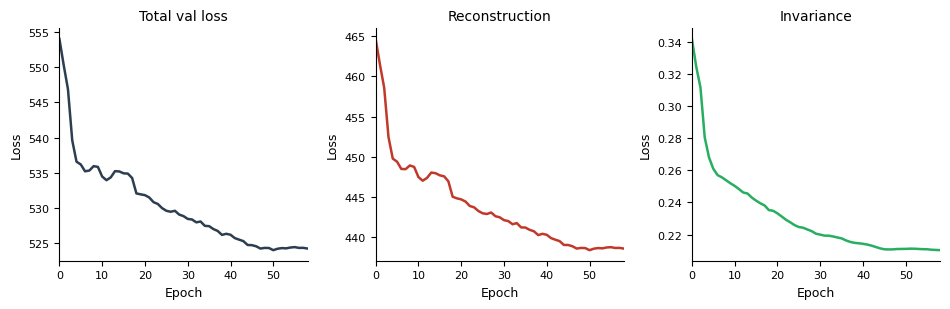

In [7]:
model_A.pl.losses(smooth=5)

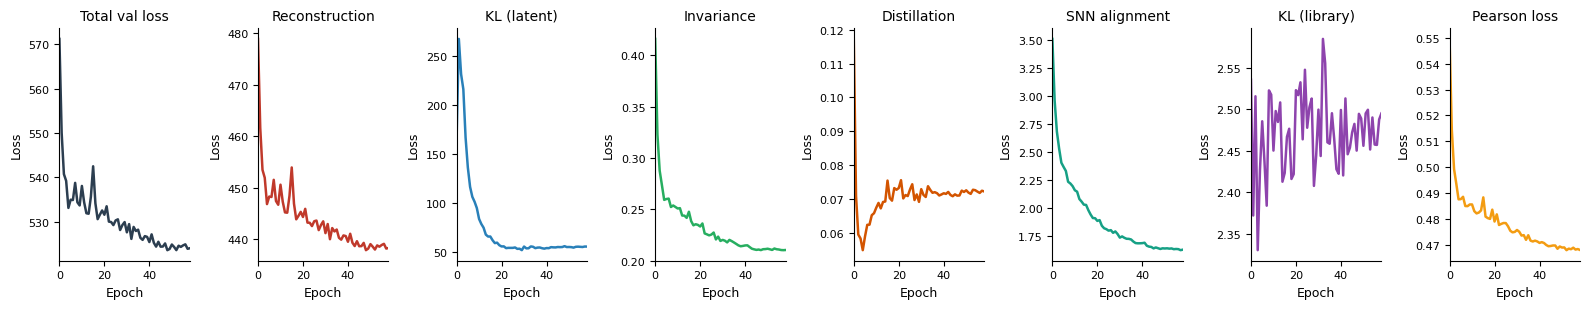

In [8]:
model_A.pl.losses(keys="all")

### A.4 — Impute

`return_norm=True` adds an area-normalised log1p layer (`imputed_norm`).  
Set `area_key=None` if your spatial data has no `cell_area` column.

In [9]:
time_start = time()
dl_A = torch.utils.data.DataLoader(sp_dataset, batch_size=512, shuffle=False)

adata_imputed_A = model_A.impute(
    dl_A,
    obs_adata=sp_adata,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
    #return_int=True is recomended for denoising data and performing downstream analyses
)
print(f"Imputation time: {(time() - time_start) / 60:.2f} minutes")
print(adata_imputed_A)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓


  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1000 gene(s) absent from obs_adata layers with sentinel -2.0
Imputation time: 1.15 minutes
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### A.5 — Evaluate

Pearson correlation between observed and imputed counts for panel genes.

In [10]:
print("=== Count space ===")
correlation_panel(adata_imputed_A, layer_real="counts", layer_imputed="imputed")

print("\n=== Log-normalised space ===")
correlation_panel(adata_imputed_A, layer_real="log1p_norm", layer_imputed="imputed_norm")

=== Count space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.5938

=== Log-normalised space ===
Valid genes (no sentinel): 307
Mean Pearson r           : 0.4980


### A.6 — Visualise

Spatial maps and UMAP for a few marker genes.  
`MS4A1` and `CD19` were in the panel; `FCRL1` and `PAX5` are purely imputed. (All B cell genes, expected to co-localise)

/tmp/ipykernel_2765509/1717081189.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


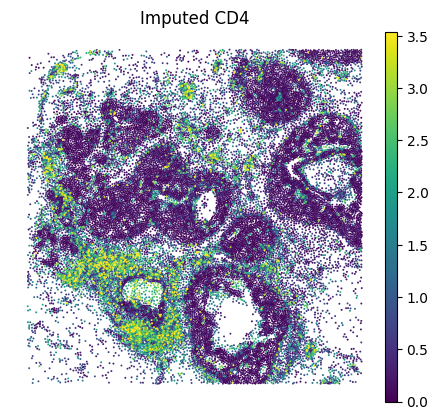

/tmp/ipykernel_2765509/1717081189.py:6: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


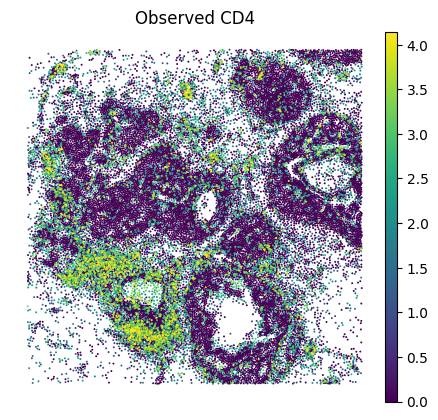

In [11]:
GENE = "CD4"  # edit as needed

sc.pl.spatial(
    adata_imputed_A, layer="imputed_norm", color=GENE, spot_size=15, vmax="p99", frameon=False, title=f"Imputed {GENE}"
)
sc.pl.spatial(
    adata_imputed_A, layer="log1p_norm", color=GENE, spot_size=15, vmax="p99", frameon=False, title=f"Observed {GENE}"
)

Spatial plots — B-cell markers:


/tmp/ipykernel_2765509/2503937333.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


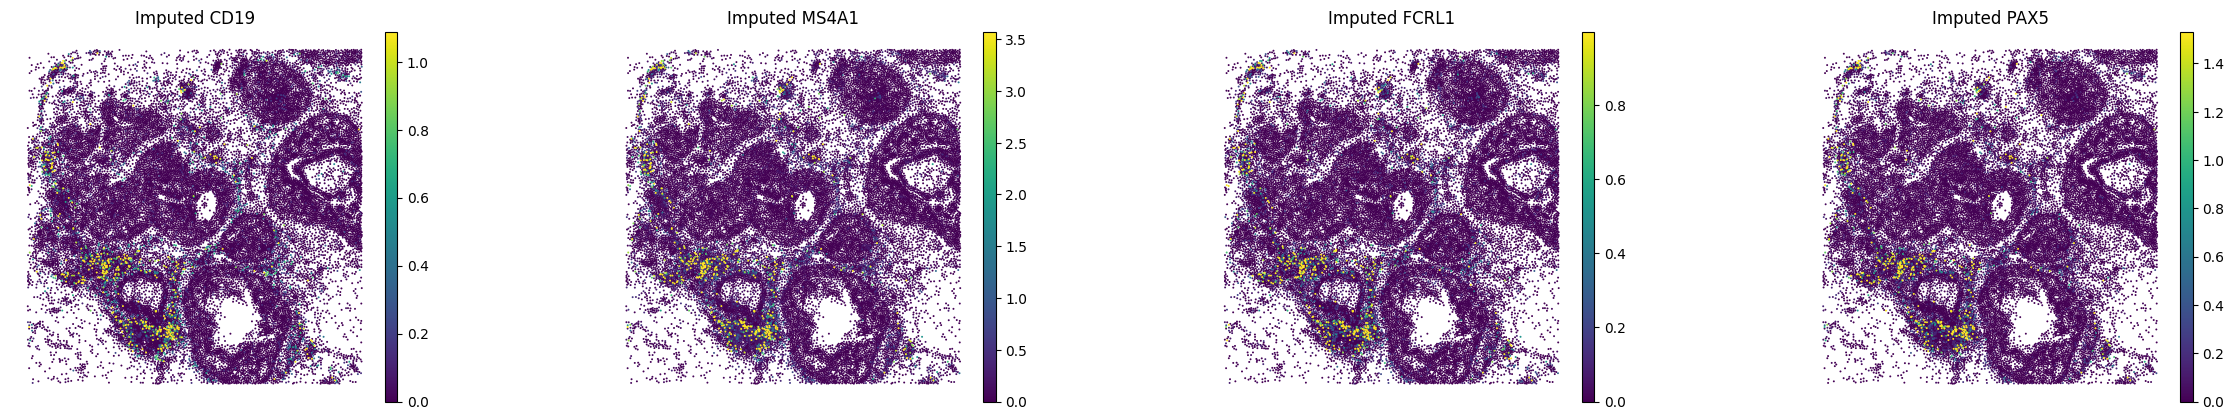

/tmp/ipykernel_2765509/2503937333.py:13: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


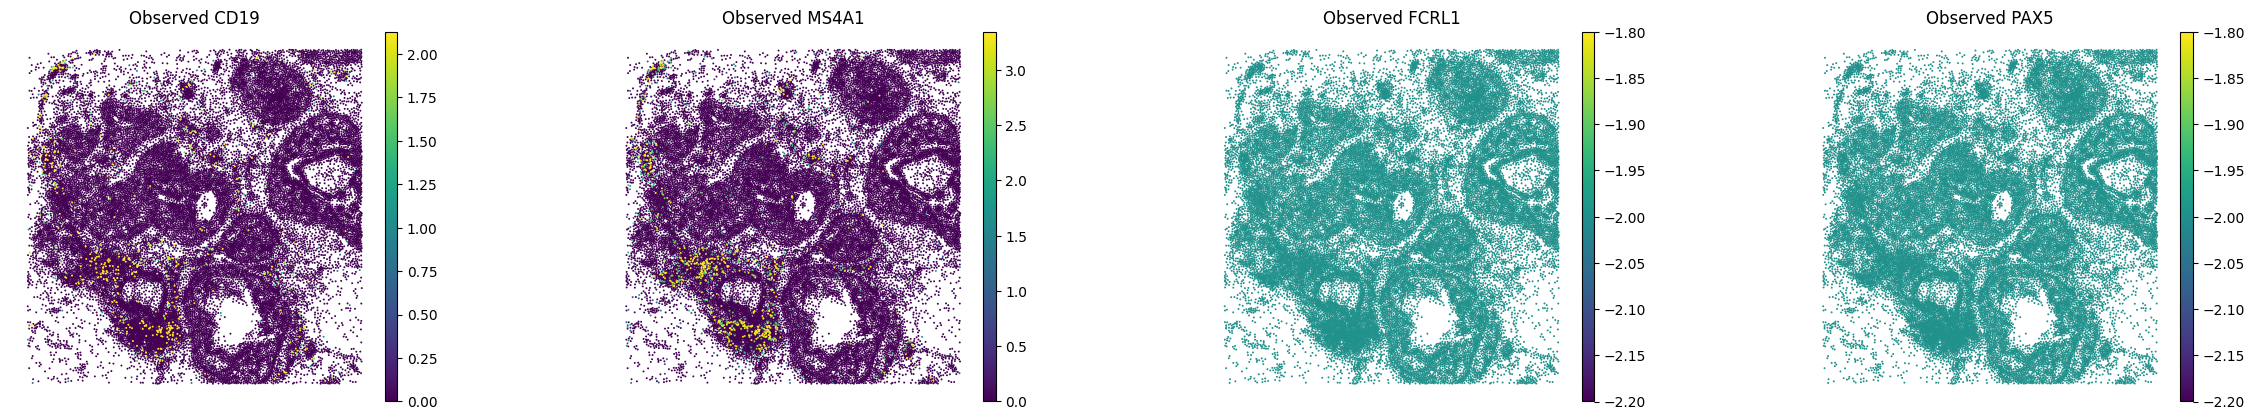

In [12]:
bcells = ["CD19", "MS4A1", "FCRL1", "PAX5"]

print("Spatial plots — B-cell markers:")
sc.pl.spatial(
    adata_imputed_A,
    layer="imputed_norm",
    color=bcells,
    spot_size=15,
    vmax="p99",
    frameon=False,
    title=[f"Imputed {g}" for g in bcells],
)
sc.pl.spatial(
    adata_imputed_A,
    layer="log1p_norm",
    color=bcells,
    spot_size=15,
    vmax="p99",
    frameon=False,
    title=[f"Observed {g}" for g in bcells],
)

### A.7 — UMAP from CellPin embeddings

Cell embeddings in `obsm["X_cellpin"]` can be used directly to build a neighborhood graph and compute a UMAP

UMAP — B-cell markers:


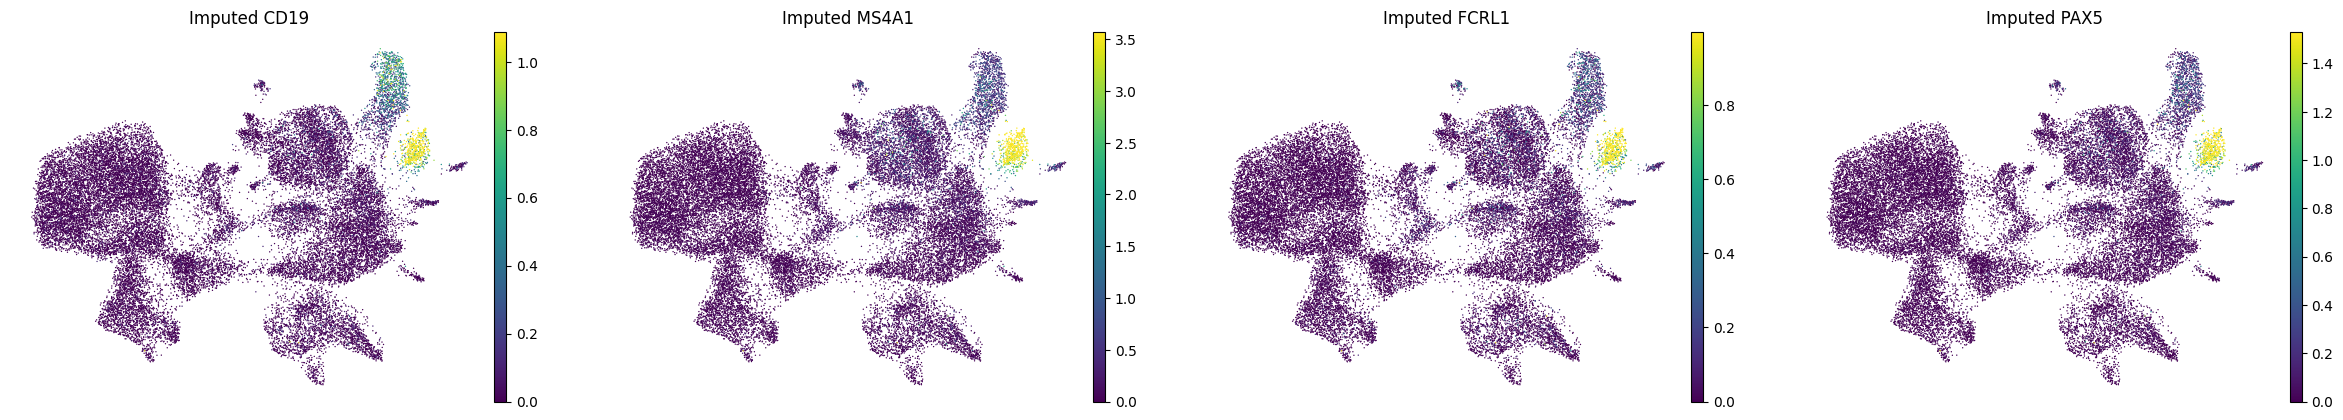

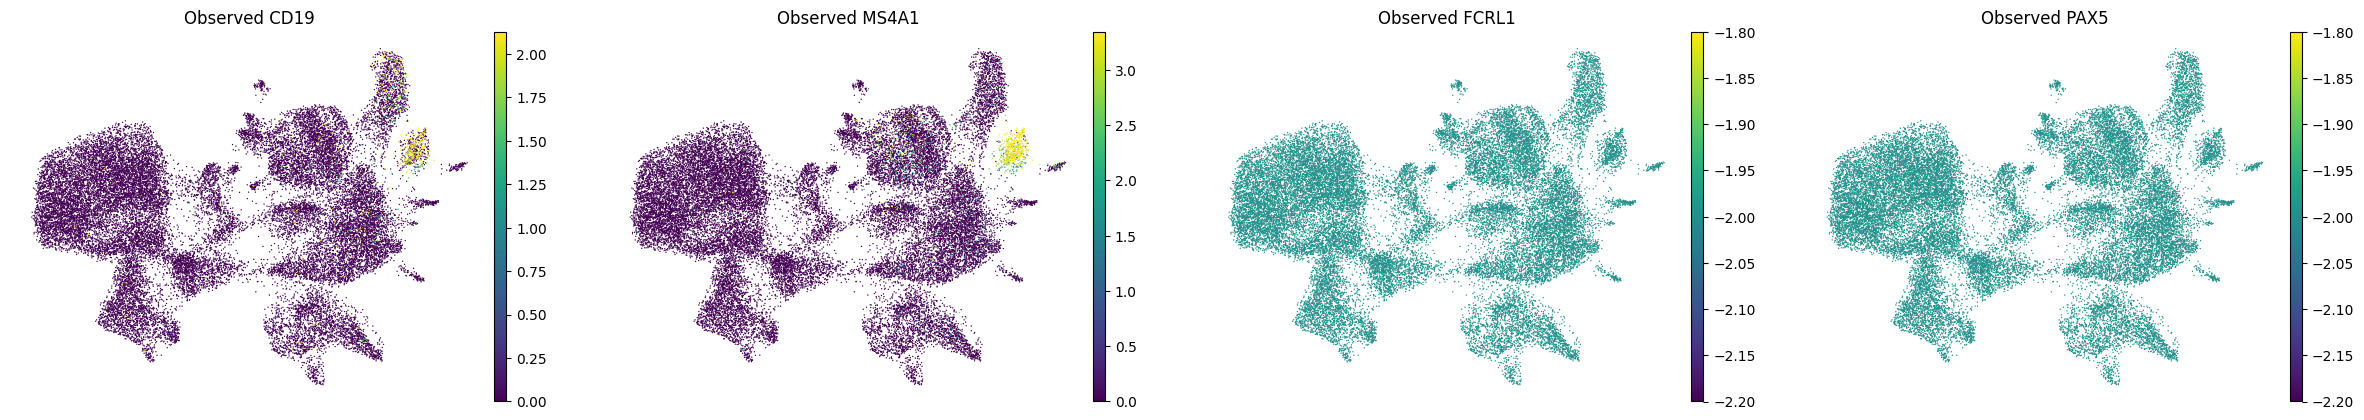

In [13]:
sc.pp.neighbors(adata_imputed_A, use_rep="X_cellpin")
sc.tl.umap(adata_imputed_A)

print("UMAP — B-cell markers:")
sc.pl.umap(adata_imputed_A, color=bcells, layer="imputed_norm", vmax="p99", title=[f"Imputed {g}" for g in bcells],frameon=False)
sc.pl.umap(adata_imputed_A, color=bcells, layer="log1p_norm", vmax="p99", title=[f"Observed {g}" for g in bcells],frameon=False)

---
# B) Held-Out Gene Evaluation

To benchmark how well CellPin imputes genes it has never seen during training, we:

1. Randomly sample a fraction of panel genes as **held-out genes**  
2. Remove them from the spatial input before `setup_data()`  
3. Train and impute as normal  
4. Compare imputed values against the ground-truth counts for those held-out genes  

The held-out Pearson correlation is the most honest imputation benchmark.

### B.1 — Define held-out genes

In [14]:
rng = np.random.default_rng(42)

# Panel genes in sc_adata order — consistent with setup_data()'s internal ordering
panel_genes_all = [g for g in sc_adata.var_names if g in set(sp_adata.var_names)]
print(f"Full panel size: {len(panel_genes_all)} genes")

HOLDOUT_FRACTION = 0.10  # hold out 10 % of the panel
n_holdout = max(1, int(len(panel_genes_all) * HOLDOUT_FRACTION))
heldout_genes = rng.choice(panel_genes_all, size=n_holdout, replace=False).tolist()
training_genes = [g for g in panel_genes_all if g not in heldout_genes]

print(f"Held-out genes : {n_holdout}  → {heldout_genes[:5]} ...")
print(f"Training panel : {len(training_genes)} genes")

Full panel size: 307 genes
Held-out genes : 30  → ['NDUFA4L2', 'CCDC6', 'LEP', 'CCL8', 'ELF3'] ...
Training panel : 277 genes


In [15]:
# Build the reduced spatial object (held-out genes removed)
sp_adata_reduced = sp_adata[:, training_genes].copy()

assert len(set(heldout_genes) & set(sp_adata_reduced.var_names)) == 0, (
    "Held-out genes still present in reduced sp_adata!"
)
print(
    f"sp_adata_reduced: {sp_adata_reduced.n_obs:,} cells × {sp_adata_reduced.n_vars:,} genes (held-out genes removed ✓)"
)

sp_adata_reduced: 30,600 cells × 277 genes (held-out genes removed ✓)


### B.2 — Setup and train

In [16]:
sc_dataset_B, sp_dataset_B = cellpin.pp.setup_data(sc_adata, sp_adata_reduced, layer=LAYER)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :   23,867 cells  ×    1,307 genes
[cellpin.pp.setup] st_adata :   30,600 cells  ×      277 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] Panel    : 277 genes overlap (100.0% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,307 genes total in sc space (1,030 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 23,867 cells, 1,307 genes total, 277 panel genes
[cellpin.pp.setup] st_dataset: 30,600 cells, 277 panel genes


In [17]:
model_B = cellpin.CellPin(sc_dataset_B)
model_B.fit(
    sc_dataset_B, pretrain_epochs=50, train_epochs=60, save_checkpoints=False
)  # save_checkpoints=True is much slower and not needed for this tutorial

Epoch 0:  39%|███▊      | 29/75 [00:01<00:01, 25.61it/s, v_num=1]          

Epoch 59: 100%|██████████| 75/75 [00:03<00:00, 19.93it/s, v_num=1, val_loss=521.0, val_reconst_loss=436.0, val_kl_loss=55.60, val_kl_l_loss=2.470, val_distill_loss=0.0726, val_snn_loss=1.660, val_inv_loss=0.214, val_snn_temperature=0.104, val_pearson_loss=0.470, train_loss=522.0, train_reconst_loss=436.0, train_kl_loss=59.50, train_kl_l_loss=2.520, train_distill_loss=0.0836, train_snn_loss=1.730, train_inv_loss=0.231, train_snn_temperature=0.104, train_pearson_loss=0.440]


### B.3 — Impute

In [18]:
dl_B = torch.utils.data.DataLoader(sp_dataset_B, batch_size=512, shuffle=False)

adata_imputed_B = model_B.impute(
    dl_B,
    obs_adata=sp_adata_reduced,
    return_norm=True,
    area_key="cell_area",
    nb_count_samples=20,
    #return_int=True is recomended for denoising data and performing downstream analyses
)
print(adata_imputed_B)

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
  [impute] Filling 1030 gene(s) absent from obs_adata layers with sentinel -2.0
AnnData object with n_obs × n_vars = 30600 × 1307
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


### B.4 — Evaluate

Two metrics:
- **Panel Pearson** — reconstruction quality on the training genes (sanity check)  
- **Held-out Pearson** — true imputation benchmark on genes the model never saw

In [19]:
print("=== Training panel genes (count space) ===")
correlation_panel(adata_imputed_B, layer_real="counts", layer_imputed="imputed")

=== Training panel genes (count space) ===
Valid genes (no sentinel): 277
Mean Pearson r           : 0.5963


In [20]:
print("=== Held-out genes — count space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,  # sp_adata (full) has ground-truth counts for held-out genes
    heldout_genes=heldout_genes,
    layer_real="counts",
    layer_imputed="imputed",
)

=== Held-out genes — count space ===
  NDUFA4L2              Pearson = 0.1975
  CCDC6                 Pearson = 0.6173
  LEP                   Pearson = 0.3429
  CCL8                  Pearson = 0.1985
  ELF3                  Pearson = 0.6551
  ENAH                  Pearson = 0.4506
  TIMP4                 Pearson = 0.2919
  KRT14                 Pearson = 0.8070
  ITGAX                 Pearson = 0.7537
  LYZ                   Pearson = 0.7676
  GNLY                  Pearson = 0.5750
  CX3CR1                Pearson = 0.4900
  SPIB                  Pearson = 0.3898
  CXCL12                Pearson = 0.8441
  KRT23                 Pearson = 0.8277
  DNAAF1                Pearson = 0.0584
  AGR3                  Pearson = 0.6253
  FOXA1                 Pearson = 0.8592
  FOXP3                 Pearson = 0.3508
  PTN                   Pearson = 0.7818
  PDCD1LG2              Pearson = 0.2287
  CCND1                 Pearson = 0.7912
  SQLE                  Pearson = 0.4533
  ANKRD30A          

In [21]:
print("=== Held-out genes — log-normalised space ===")
correlation_heldout(
    adata_imputed_B,
    sp_adata_full=sp_adata,
    heldout_genes=heldout_genes,
    layer_real="log1p_norm",
    layer_imputed="imputed_norm",
)

=== Held-out genes — log-normalised space ===
  NDUFA4L2              Pearson = 0.1717
  CCDC6                 Pearson = 0.5261
  LEP                   Pearson = 0.1451
  CCL8                  Pearson = 0.1529
  ELF3                  Pearson = 0.6506
  ENAH                  Pearson = 0.3184
  TIMP4                 Pearson = 0.0974
  KRT14                 Pearson = 0.7578
  ITGAX                 Pearson = 0.5899
  LYZ                   Pearson = 0.6539
  GNLY                  Pearson = 0.3986
  CX3CR1                Pearson = 0.4187
  SPIB                  Pearson = 0.3675
  CXCL12                Pearson = 0.7626
  KRT23                 Pearson = 0.7281
  DNAAF1                Pearson = 0.0097
  AGR3                  Pearson = 0.5790
  FOXA1                 Pearson = 0.8434
  FOXP3                 Pearson = 0.3118
  PTN                   Pearson = 0.7032
  PDCD1LG2              Pearson = 0.1542
  CCND1                 Pearson = 0.6785
  SQLE                  Pearson = 0.3021
  ANKRD30A 

### B.5 — Visualise held-out genes

Compare imputed vs. observed spatial expression for a few held-out genes with strong Pearson correlation.

/tmp/ipykernel_2765509/3142780183.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


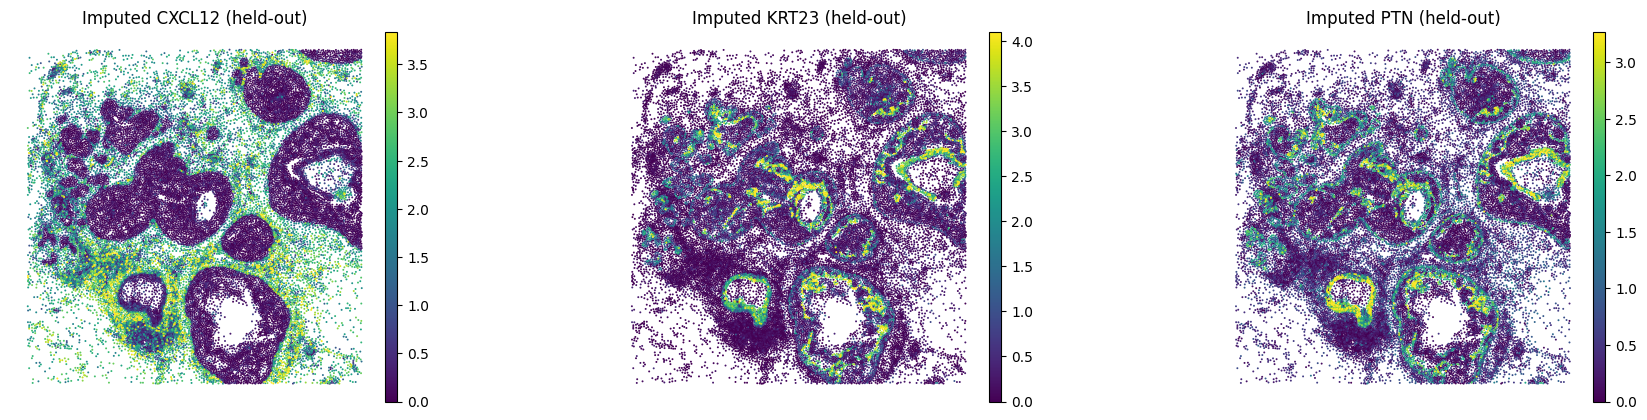

/tmp/ipykernel_2765509/3142780183.py:13: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


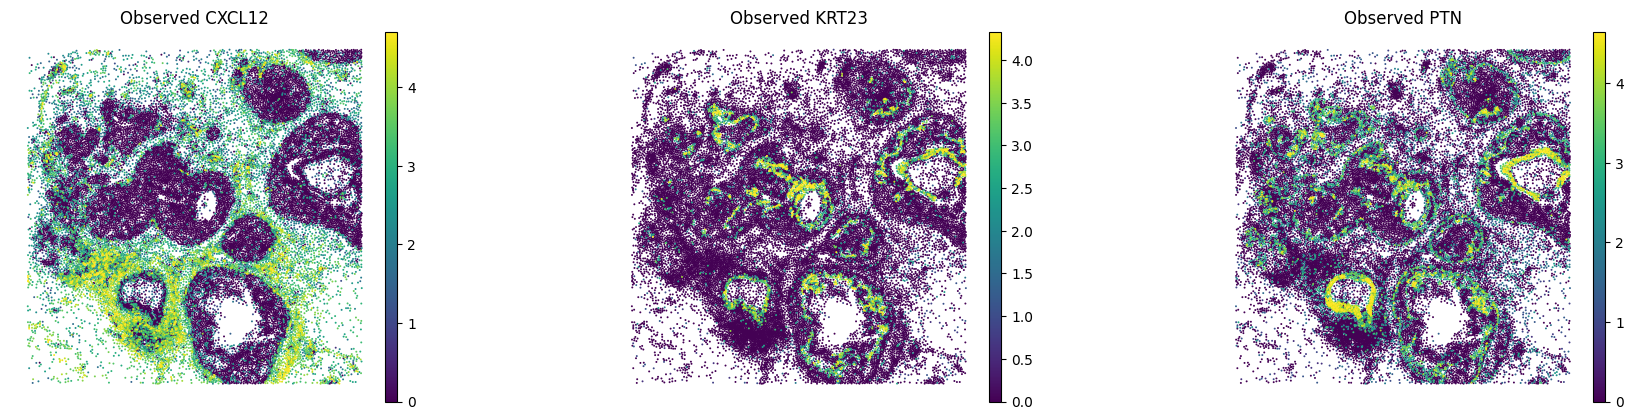

In [22]:
# Edit: pick held-out genes with high Pearson from the evaluation above
GENES_HELDOUT = ["CXCL12", "KRT23", "PTN"]

sc.pl.spatial(
    adata_imputed_B,
    layer="imputed_norm",
    color=GENES_HELDOUT,
    spot_size=15,
    vmax="p99",
    frameon=False,
    title=[f"Imputed {g} (held-out)" for g in GENES_HELDOUT],
)
sc.pl.spatial(
    sp_adata,
    layer="log1p_norm",
    color=GENES_HELDOUT,
    spot_size=15,
    vmax="p99",
    frameon=False,
    title=[f"Observed {g}" for g in GENES_HELDOUT],
)